# Ground-truth models

The two random-forest regressors that stand in for experiments in the BO campaigns,
built with ARMOTE-MO (`resource_allocation.armote_multi_output`). This notebook produces

- Figure 2, `figures/fig2_parity_plots.png` and `.pdf`
- one ARMOTE parity figure per system, with individual panels, in `figures/parity/`
- `design_space_inputs.csv` and `design_space_predictions.csv` for each system in
  `ground_truth_models/`, which the campaigns and the paper figures read

Run it from the repository root after `pip install -e ".[surrogate]"`.

With `RETRAIN = False` the notebook evaluates the committed models on the same 80/20
split ARMOTE-MO used (`random_state=42`), which reproduces the published parity plots
and $R^2$ values. `RETRAIN = True` reruns the ARMOTE-MO hyperparameter search and
overwrites the models in `ground_truth_models/`. The Optuna search is not seeded, so
retrained models will differ from the ones behind the published campaigns.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from resource_allocation import armote_multi_output as armote
from resource_allocation.design_space import DesignSpace
from resource_allocation.experiments.config import EXPERIMENTS

RETRAIN = False

REPO = Path.cwd()
GROUND_TRUTH = REPO / "ground_truth_models"
DATA = GROUND_TRUTH / "data"
FIGURES = REPO / "figures"
assert GROUND_TRUTH.is_dir(), "Run this notebook from the repository root."
FIGURES.mkdir(exist_ok=True)

PARAM_SPACES = {
    "RFR": {
        "n_estimators": ("int", 10, 150),
        "max_depth": ("int", 10, 150),
        "min_samples_split": ("int", 2, 20),
        "min_samples_leaf": ("int", 1, 20),
    }
}

In [2]:
def fit_or_load(system, X, y, output_labels):
    """Train and test predictions of a system's RFR, retrained first if RETRAIN is set."""
    folders = {
        "models": GROUND_TRUTH / system / "models",
        "plots": FIGURES / "parity" / system,
        "studies": GROUND_TRUTH / system / "studies",
        "results": GROUND_TRUTH / system,
    }
    if RETRAIN:
        models = {"Linear": LinearRegression(), "RFR": RandomForestRegressor()}
        armote.run_workflow(X, y, models, PARAM_SPACES, output_labels=output_labels,
                            folder_dict={k: str(v) for k, v in folders.items()},
                            separate_panels=True)

    x_scaler, y_scaler, model = (joblib.load(folders["models"] / f"{name}.pkl")
                                 for name in ("x_scaler", "y_scaler", "RFR_best_model"))
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    pred_train = y_scaler.inverse_transform(model.predict(x_scaler.transform(X_train)))
    pred_test = y_scaler.inverse_transform(model.predict(x_scaler.transform(X_test)))

    if not RETRAIN:
        armote.plot_yy_multi_output(y_train, pred_train, y_test, pred_test, "RFR",
                                    save_folder=str(folders["plots"]),
                                    output_labels=output_labels, n_cols=len(output_labels),
                                    separate_panels=True)
    return y_train.values, pred_train, y_test.values, pred_test


def metrics(predictions, targets):
    y_train, pred_train, y_test, pred_test = predictions
    return pd.DataFrame([
        {
            "output": target,
            "train R2": r2_score(y_train[:, i], pred_train[:, i]),
            "test R2": r2_score(y_test[:, i], pred_test[:, i]),
            "train RMSE": np.sqrt(mean_squared_error(y_train[:, i], pred_train[:, i])),
            "test RMSE": np.sqrt(mean_squared_error(y_test[:, i], pred_test[:, i])),
        }
        for i, target in enumerate(targets)
    ]).round(4)


def predict_design_space(system, experiment, output_columns):
    """Enumerate an experiment's design space, predict it, and save both as CSV."""
    config = EXPERIMENTS[experiment]
    space = DesignSpace(config["components"], step=config["step"], groups=config["groups"],
                        seed=config["setup_seed"])
    inputs = pd.DataFrame(space.space, columns=[c[0] for c in config["components"]])

    models_dir = GROUND_TRUTH / system / "models"
    x_scaler, y_scaler, model = (joblib.load(models_dir / f"{name}.pkl")
                                 for name in ("x_scaler", "y_scaler", "RFR_best_model"))
    predictions = pd.DataFrame(
        y_scaler.inverse_transform(model.predict(x_scaler.transform(inputs))),
        columns=output_columns,
    )
    inputs.to_csv(GROUND_TRUTH / system / "design_space_inputs.csv", index=False)
    predictions.to_csv(GROUND_TRUTH / system / "design_space_predictions.csv", index=False)
    return predictions.describe().loc[["min", "max"]]

## Fe-Co-Ni soft magnets

Training data from Padhy et al. (2024): 1,208 compositions over 15 elements, in at.%.
ARMOTE-MO fits all six measured properties jointly. The campaigns optimize $M_s$,
$\log H_c$ and $\log H_V$.

In [3]:
MAGNETS = "FeCoNiVMoCrCuMnCWTaNbAlTiSi-Magnets"
MAGNETS_TARGETS = ["Ms", "LogHC", "LogTC", "LogER", "LogElong", "LogHV"]
MAGNETS_LABELS = [
    r"$M_s$ (T)",
    r"$\log\,H_c$ ($\log$ A/m)",
    r"$\log\,T_c$ ($\log$ K)",
    r"$\log\,\rho$ ($\log\,\mu\Omega$ cm)",
    r"$\log\,\delta$ ($\log$ %)",
    r"$\log\,H_V$ ($\log$ HV)",
]

magnets_data = pd.read_csv(DATA / "FeNiCo_comp-prop_imp.csv")
magnets_elements = [c[0] for c in EXPERIMENTS["Magnets-MAIN"]["components"]]
magnets = fit_or_load(MAGNETS, magnets_data[magnets_elements] / 100,
                      magnets_data[MAGNETS_TARGETS], MAGNETS_LABELS)
metrics(magnets, MAGNETS_TARGETS)

  Y-Y plot saved to: /home/trippr5118/research/resource-allocation/figures/parity/FeCoNiVMoCrCuMnCWTaNbAlTiSi-Magnets/RFR_yy_plot.png, /home/trippr5118/research/resource-allocation/figures/parity/FeCoNiVMoCrCuMnCWTaNbAlTiSi-Magnets/RFR_yy_plot.pdf


  6 individual Y-Y panels saved to: /home/trippr5118/research/resource-allocation/figures/parity/FeCoNiVMoCrCuMnCWTaNbAlTiSi-Magnets/yy_panels


,output,train R2,test R2,train RMSE,test RMSE
0,Ms,0.9848,0.9717,0.0649,0.0850
1,LogHC,0.9227,0.9116,0.2581,0.2867
2,LogTC,0.9786,0.9797,0.0168,0.0163
3,LogER,0.8814,0.7817,0.0905,0.1222
4,LogElong,0.9456,0.8539,0.1117,0.1687
5,LogHV,0.8707,0.7747,0.0653,0.0784


In [4]:
predict_design_space(MAGNETS, "Magnets-MAIN", MAGNETS_TARGETS)

[DesignSpace] Generated 331,227 valid compositions for 15 components with 2 group(s): Fe, Co, Ni, V, Mo, Cr, Cu, Mn, C, W, Ta, Nb, Al, Ti, Si


,Ms,LogHC,LogTC,LogER,LogElong,LogHV
min,0.367504,0.335448,2.544542,0.764454,-0.254683,2.019510
max,2.483159,3.479111,3.141834,1.836990,1.901668,2.702045


## Ti-V-Nb-Mo-Hf-Ta-W refractory alloys (RHEA)

Training data from Hastings et al. (2025): 1,000 CALPHAD-modeled compositions over
seven elements, as mole fractions. Outputs are melting temperature and room-temperature
density.

In [5]:
RHEA = "TiVNbMoHfTaW-MeltingVsDensity"
RHEA_TARGETS = ["Melting Point (K)", "PROP RT Density (g/cm3)"]
RHEA_LABELS = [r"$T_m$ (K)", r"$\rho$ (g cm$^{-3}$)"]

rhea_data = pd.read_excel(DATA / "refractory-meltingvsdensity.xlsx")
rhea_elements = [c[0] for c in EXPERIMENTS["MP-D_MAIN"]["components"]]
rhea = fit_or_load(RHEA, rhea_data[rhea_elements], rhea_data[RHEA_TARGETS], RHEA_LABELS)
metrics(rhea, RHEA_TARGETS)

  Y-Y plot saved to: /home/trippr5118/research/resource-allocation/figures/parity/TiVNbMoHfTaW-MeltingVsDensity/RFR_yy_plot.png, /home/trippr5118/research/resource-allocation/figures/parity/TiVNbMoHfTaW-MeltingVsDensity/RFR_yy_plot.pdf


  2 individual Y-Y panels saved to: /home/trippr5118/research/resource-allocation/figures/parity/TiVNbMoHfTaW-MeltingVsDensity/yy_panels


,output,train R2,test R2,train RMSE,test RMSE
0,Melting Point (K),0.9813,0.8909,9.6999,23.2199
1,PROP RT Density (g/cm3),0.9849,0.9286,0.0872,0.1880


In [6]:
predict_design_space(RHEA, "MP-D_MAIN", EXPERIMENTS["MP-D_MAIN"]["objective_names"])

[DesignSpace] Generated 9,454 valid compositions for 7 components: Ti, V, Nb, Mo, Hf, Ta, W


,Melting Point (K),Density (g/cm3)
min,2619.682437,8.534365
max,2903.190786,11.212351


## Figure 2

Parity plots for the five optimized objectives, drawn with ARMOTE-MO's panel style.

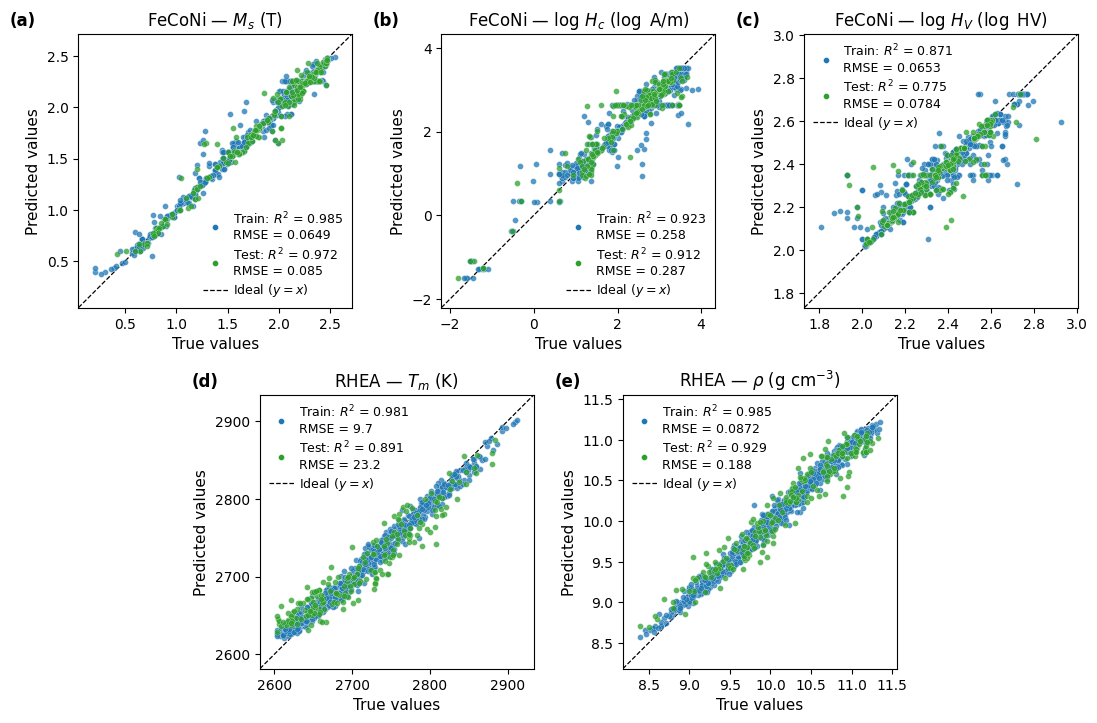

In [7]:
panels = [
    ("FeCoNi", magnets, MAGNETS_TARGETS.index("Ms"), MAGNETS_LABELS[0]),
    ("FeCoNi", magnets, MAGNETS_TARGETS.index("LogHC"), MAGNETS_LABELS[1]),
    ("FeCoNi", magnets, MAGNETS_TARGETS.index("LogHV"), MAGNETS_LABELS[5]),
    ("RHEA", rhea, 0, RHEA_LABELS[0]),
    ("RHEA", rhea, 1, RHEA_LABELS[1]),
]
slots = [(0, slice(0, 2)), (0, slice(2, 4)), (0, slice(4, 6)), (1, slice(1, 3)), (1, slice(3, 5))]

with plt.rc_context(armote._PUBLICATION_RC):
    fig = plt.figure(figsize=(3.6 * 3, 3.6 * 2))
    grid = fig.add_gridspec(2, 6)
    for letter, (system, (y_train, pred_train, y_test, pred_test), i, label), (row, cols) in zip(
            "abcde", panels, slots):
        ax = fig.add_subplot(grid[row, cols])
        armote._draw_yy_panel(ax, y_train[:, i], pred_train[:, i], y_test[:, i], pred_test[:, i],
                              f"{system} — {label}")
        ax.set_title(f"({letter})", loc="left", x=-0.25, fontweight="bold", pad=6)
    fig.tight_layout(pad=0.6, w_pad=1.2, h_pad=1.2)
    fig.savefig(FIGURES / "fig2_parity_plots.png", dpi=600, bbox_inches="tight")
    fig.savefig(FIGURES / "fig2_parity_plots.pdf", bbox_inches="tight")
    plt.show()